PYTHON: /media/monte_share/conda_envs/dataproc/bin/python
LD_LIBRARY_PATH: None
CONDA_PREFIX: /media/monte_share/conda_envs/dataproc
Running smooth estimate 365-day window

jd_vecs are exactly equal - stacking individual sc arrays


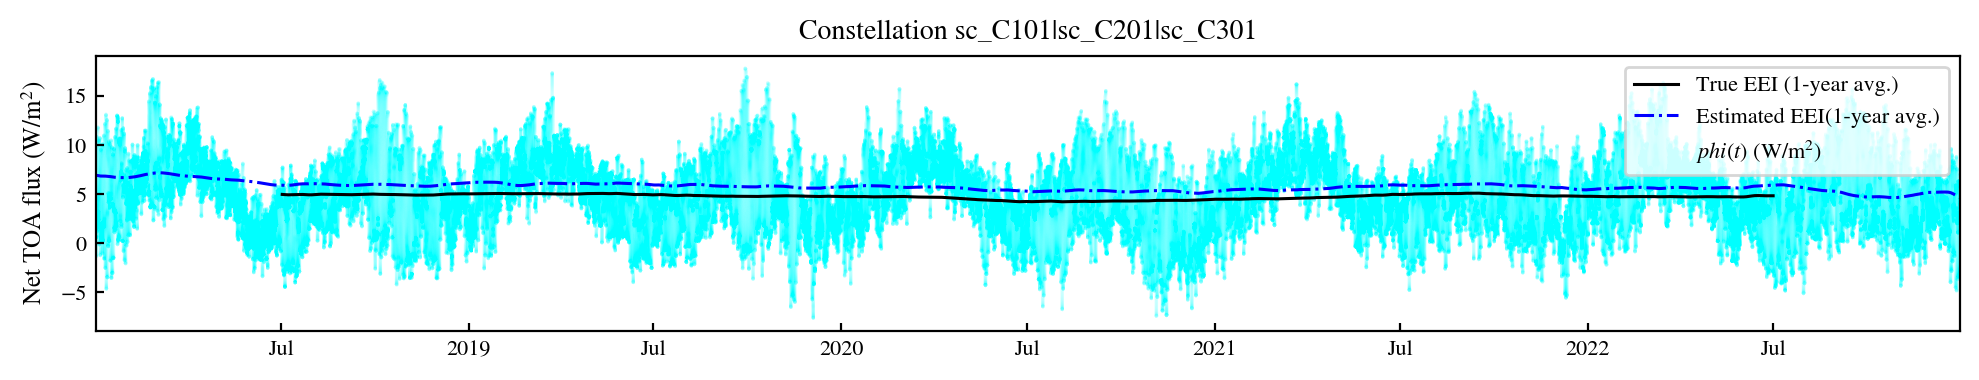

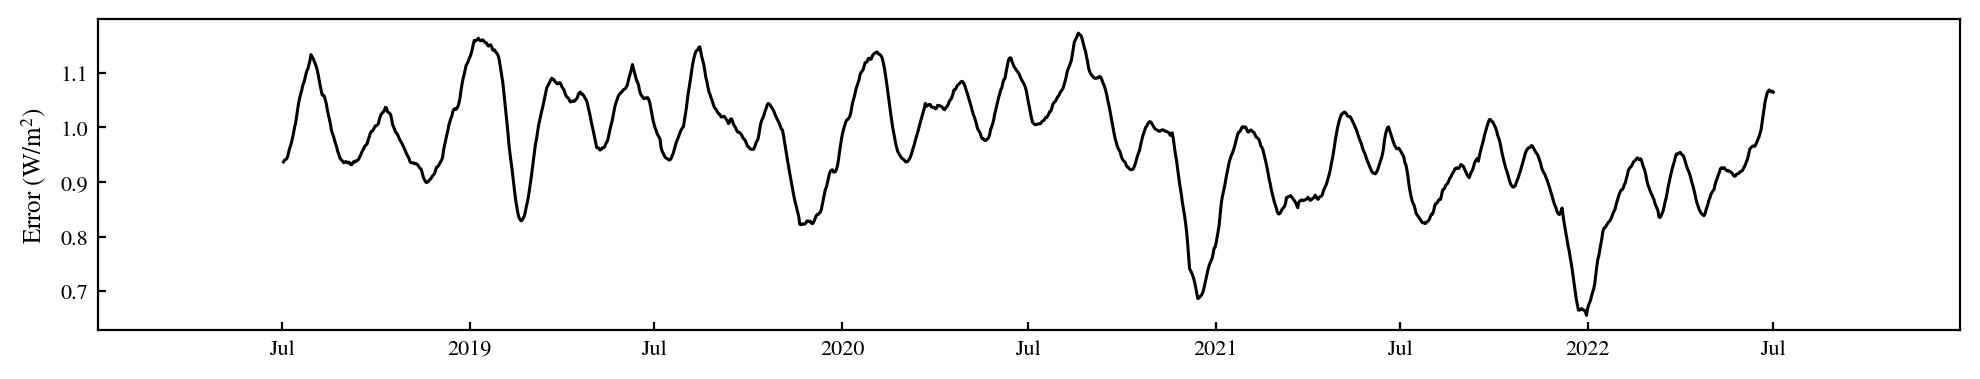

In [1]:
import numpy as np
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
%matplotlib inline

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)

SB_constellation = ['sc_C101', 'sc_C201', 'sc_C301']

combinations = itertools.combinations((SB_constellation), 3)

input_names = ['case_5_years_' + sc_name for sc_name in SB_constellation]
all_altitudes = get_all_orbital_sma_0(input_names) - constants.earth_radius(units='km')
assert(len(np.unique(all_altitudes))==1)

smoothing_windows_days = [365] #[1, 7, 30, 182, 365]
smoothing_windows_names = ['1-year'] # ['1-day', '1-week', '1-month', '6-month', '1-year']

for window_name, window_days in zip(smoothing_windows_names, smoothing_windows_days):
    print(f"Running smooth estimate {window_days}-day window")
    print("")
    EEI_smooth_true = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=window_days, 
                                      out_length_mode='same_with_nans')
    EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

    EEI_smooth_estimated = np.zeros_like(EEI_smooth_true_coarse)
    jd_windows = np.zeros((len(mid_day_jd_array), 2))
    for i, mid_day_jd in enumerate(mid_day_jd_array):
        jd_windows[i,:] = [
            max(mid_day_jd - window_days/2, mid_day_jd_array[0]  - 0.5),
            min(mid_day_jd + window_days/2, mid_day_jd_array[-1] + 0.5),
        ]
    
    EEI_smooth_estimated = estimate_EEI_avg('case_5_years', sc_names=SB_constellation, 
                                    altitude=np.unique(all_altitudes), jd_windows=jd_windows, 
                                    n_lon=360*2, n_lat=180*2, frame="SFF", fill_method="theta_s_fit_accurate",
                                    make_plots=False)
        
    Plotter.plot_time_series(mid_day_jd_array,
                        {'True EEI ('+window_name+' avg.)': EEI_smooth_true_coarse,
                        'Estimated EEI('+window_name+' avg.)': EEI_smooth_estimated},
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        y_scatter_dict={'$phi(t)$ (W/m$^2$)': (full_jd_array, EEI_time_series_180x360)},
                        scatter_alpha=0.007,
                        title='Constellation '+'|'.join(SB_constellation))
    
    Plotter.plot_time_series(mid_day_jd_array,
                        {'Estimation error': EEI_smooth_estimated-EEI_smooth_true_coarse},
                        f_width=2.5, f_height=0.5,
                        ylabel='Error (W/m$^2$)')


In [2]:
idx_0 = np.where(~np.isnan(EEI_smooth_true_coarse))[0][0]
EEI_smooth_estimated[idx_0]

error = EEI_smooth_estimated-EEI_smooth_true_coarse
from SpaceBalls.utils import nanrms
nanrms(error)

np.float64(0.9725015152379514)